In [1]:
# Data manipulation and numerical computation
import numpy as np
import pandas as pd
import os

# pandas all columns display
pd.set_option('display.max_columns', None)

# Load data

In [2]:
# before: path = "../../data/processed/"
path = "data/processed"

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

df_copy = df.copy()

end_idx = df.columns.get_loc("Watershed")
new_cols = df.columns[: end_idx + 1]

# Keep until Watershed
df = df.loc[:, new_cols].copy()
df = df.drop(columns=['CodeSite_SamplingOperations_x', 'Watershed'])

# add the ibd column
df['IBD'] = df_copy['IBD']
df

SamplingOperations_code Date_SamplingOperation  \
2703       S02115200_20070702             2007-07-02   
33984      S05218450_20070709             2007-07-09   
33929      S05217350_20070709             2007-07-09   
48228      S05235850_20070709             2007-07-09   
35408      S05234290_20070709             2007-07-09   
...                       ...                    ...   
42720      S06580577_20230907             2023-09-07   
35760      S06001284_20230907             2023-09-07   
35783      S06001533_20230907             2023-09-07   
38878      S06137040_20231011             2023-10-11   
38873      S06137014_20231011             2023-10-11   

       TotalAbundance_SamplingOperation  Achaa01  Achac01  Achaf01  Achaf02  \
2703                                400      NaN      NaN      NaN      NaN   
33984                               400      NaN      NaN     12.5      NaN   
33929                               400      NaN      NaN      NaN      NaN   
48228                               400      NaN      NaN      2.5      NaN   
35408                               400      NaN      NaN      7.5      NaN   
...                                 ...      ...      ...      ...      ...   
42720                               426      NaN      NaN      NaN      NaN   
35760                               421      NaN      NaN      NaN      NaN   
35783                               401      NaN      NaN      NaN      NaN   
38878                               400      NaN      NaN      NaN      NaN   
38873                               405      NaN      NaN      NaN      NaN   

       Achal01  Acham01  Achan01  Achat01    Achat02  Achat03  Achba01  \
2703       NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN   5.000000      NaN      NaN   
48228      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
35408      NaN      NaN      NaN      NaN  20.000000      NaN      NaN   
...        ...      ...      ...      ...        ...      ...      ...   
42720      NaN      NaN      NaN      NaN   4.694836      NaN      NaN   
35760      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN  14.962594      NaN      NaN   
38878      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
38873      NaN      NaN      NaN      NaN  69.135802      NaN      NaN   

       Achbi01  Achbi02  Achbr01  Achca01  Achca02  Achca03  Achca04  Achch01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

       Achcl01  Achco01  Achco02  Achco03  Achco04  Achcr01  Achcy01  Achda01  \
2703       NaN      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      2.5   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...    

In [3]:
achat = df_copy[df_copy[['Achat01', 'Achat02', 'Achat03']].notnull().all(axis=1)]
achat

,SamplingOperations_code,CodeSite_SamplingOperations_x,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaa01,Achac01,Achaf01,Achaf02,Achal01,Acham01,Achan01,Achat01,Achat02,Achat03,Achba01,Achbi01,Achbi02,Achbr01,Achca01,Achca02,Achca03,Achca04,Achch01,Achcl01,Achco01,Achco02,Achco03,Achco04,Achcr01,Achcy01,Achda01,Achda02,Achde01,Achde02,Achde03,Achdi01,Achdi02,Achdr01,Achel01,Achen01,Acheu01,Achex01,Achex02,Achex03,Achfl01,Achfr01,Achfu01,Achge01,Achgr01,Achgr02,Achgr03,Achha01,Achhe01,Achhi01,Achho01,Achho02,Achho03,Achhu01,Achim01,Achim02,Achim03,Achin01,Achin02,Achja01,Achja02,Achjo01,Achko01,Achkr01,Achkr02,Achkr03,Achkr04,Achku01,Achla01,Achla02,Achla03,Achla04,Achla05,Achla06,Achle01,Achle02,Achli01,Achli02,Achli03,Achli04,Achlo01,Achlu01,Achlu02,Achma01,Achmi01,Achmi02,Achmi03,Achmo01,Achmo02,Achna01,Achna02,Achne01,Achni01,Achno01,Achob01,Achpa01,Achpe01,Achpe02,Achpf01,Achpl01,Achpo01,Achpr01,Achpr02,Achps01,Achps02,Achps03,Achps04,Achpu01,Achpy01,Achre01,Achri01,Achro01,Achro02,Achro03,Achro04,Achru01,Achru02,Achsa01,Achsc01,Achse01,Achse02,Achsi01,Achst01,Achst02,Achst03,Achst04,Achsu01,Achsu02,Achsu03,Achsu04,Achsu05,Achsu06,Achsu07,Achte01,Achth01,Achtr01,Achtr02,Achtr03,Achtu01,Achzh01,Achzi01,Actde01,Actno01,Actro01,Actse01,Actsp01,Actsu01,Actvu01,Adlaq01,Adlba01,Adlbr01,Adlbr02,Adlmi01,Adlmu01,Adlmu02,Adlpa01,Adlsu01,Afrre01,Ampae01,Ampaf01,Ampal01,Ampat01,Ampbi01,Ampbu01,Ampco01,Ampcu01,Ampde01,Ampdi01,Ampdi02,Ampdu01,Ampei01,Ampex01,Ampfo01,Ampfo02,Amphe01,Amphi01,Ampin01,Ampin02,Ampli01,Ampma01,Ampme01,Ampmi01,Ampmi02,Ampmo01,Ampne01,Ampne02,Ampno01,Ampol01,Ampov01,Amppa01,Amppe01,Amppe02,Amppo01,Amppo02,Amppr01,Ampps01,Ampri01,Ampst01,Ampst02,Ampsu01,Ampsu02,Ampsu03,Ampsu04,Amptu01,Ampve01,Ampve02,Ampvi01,Anaba01,Anemi01,Anetu01,Anoeu01,Anoga01,Anoin01,Anosp01,Astfo01,Aulal01,Aulam01,Aulbr01,Aulcr01,Aulcr02,Auldi01,Aulgr01,Aulis01,Aulit01,Aulli01,Aulni01,Aulpa01,Aulps01,Aulps02,Aulsu01,Aulsu02,Aulte01,Aulva01,Azpno01,Bacci01,Bacpa01,Bacul01,Berru01,Bible01,Birbi01,Brabr01,Braca01,Brali01,Brane01,Brane02,Brapr01,Braps01,Breke01,Calae01,Calae02,Calal01,Calau01,Calba01,Calbi01,Calfa01,Calfo01,Calfo02,Calhy01,Calla01,Calla02,Calla03,Calle01,Calmi01,Calpa01,Calpu01,Calsc01,Calsi01,Caltr01,Calve01,Calwe01,Camcy01,Camhi01,Capcr01,Catad01,Cavpa01,Cenre01,Cergr01,Chaal01,Chabe01,Chafa01,Chamu01,Chare01,Charh01,Chasc01,Chath01,Clico01,Cliin01,Cocbr01,Cocca01,Coccl01,Cocco01,Cocde01,Cocdi01,Cocdi02,Coceu01,Cocgr01,Cochu01,Cochu02,Cocin01,Cocla01,Cocle01,Cocli01,Cocme01,Cocne01,Cocne02,Cocne03,Cocpa01,Cocpe01,Cocpl01,Cocps01,Cocps02,Cocre01,Cocro01,Cocsc01,Cocse01,Cocsu01,Conwe01,Cosco01,Cosla01,Cosla02,Craac01,Craac02,Craha01,Crari01,Crasu01,Crasv01,Cravi01,Crazi01,Creru01,Creth01,Ctepu01,Cycat01,Cycbo01,Cycco01,Cyccy01,Cycde01,Cycde02,Cycdi01,Cycdu01,Cycex01,Cycgl01,Cycir01,Cyckr01,Cycku01,Cycme01,Cycme02,Cycmi01,Cycop01,Cycpl01,Cycpl02,Cycps01,Cycsc01,Cycsc02,Cycst01,Cycst02,Cycst03,Cycst04,Cycsu01,Cycth01,Cycwo01,Cylgr01,Cymaf01,Cymaf02,Cymal01,Cymal02,Cymam01,Cyman01,Cyman02,Cyman03,Cyman04,Cymap01,Cymas01,Cymbe01,Cymbi01,Cymbr01,Cymbu01,Cymci01,Cymco01,Cymcu01,Cymcy01,Cymdi01,Cymdo01,Cymeh01,Cymel01,Cymel02,Cymex01,Cymex02,Cymex03,Cymfl01,Cymfr01,Cymga01,Cymhe01,Cymhe02,Cymhu01,Cymin01,Cymin02,Cymin03,Cymka01,Cymko01,Cymku01,Cymla01,Cymla02,Cymla03,Cymlu01,Cymma01,Cymme01,Cymme02,Cymmi01,Cymna01,Cymna02,Cymne01,Cymne02,Cymne03,Cymob01,Cymob02,Cympa01,Cympe01,Cympe02,Cympl01,Cympr01,Cympr02,Cympr03,Cympu01,Cymre01,Cymrh01,Cymru01,Cymsi01,Cymsi02,Cymsi03,Cymso01,Cymsp01,Cymst01,Cymsu01,Cymsu02,Cymsu03,Cymsu04,Cymsu05,Cymsu06,Cymsu07,Cymsu08,Cymsu09,Cymtr01,Cymtr02,Cymtu01,Cymtu02,Cymtu03,Cymtu04,Cymve01,Cymvu01,Delal01,Delap01,Delco01,Delde01,Delde02,Delkr01,Delve01,Dener01,Denfr01,Denku01,Denpa01,Dense01,Densu01,Densu02,Denta01,Dente01,Diabi01,Diaco01,Diade01,Diaeh01,Diaga01,Diahy01,Diame01,Diamo01,Diapa01,Diapr01,Diapy01,Diate01,Diate02,Diavi01,Diavu01,Dicda01,Didge01,Dimna01,Dipab01,Dipae01,Dipbo01,D

They are **different species** with **different ecology**, so their IBD calibrations typically differ. Do **not** collapse them for official IBD; for ML, collapse only if validated on held-out sites.

* **Achnanthes coarctata**: aerophilic, often on wet moss/rocks; distinct habitat signal. ([Diatoms.org][1])
* **Achnanthes conspicua**: now **Platessa conspicua** (reclassified), so collapsing by the “Achco” stem mixes genera. ([Diatoms.org][2])
* **Achnanthes convergens**: reported as prevalent and adaptable in rivers, implying a different tolerance profile. ([MDPI][3])

If you lack the s,v table, assume they are not interchangeable. Collapse only if genus weight is small and grouped-CV shows unchanged MAE after merging.

[1]: https://diatoms.org/species/47801/achnanthes_coarctata?utm_source=chatgpt.com "Achnanthes coarctata | Species"
[2]: https://diatoms.org/genera/platessa/guide?utm_source=chatgpt.com "Guide to Platessa | Genera"
[3]: https://www.mdpi.com/2073-4441/14/6/956?utm_source=chatgpt.com "A Case Study in the Han River, South Korea"


# Knwon NaN values percentage per column

In [4]:
# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

In [5]:
# keep the columns with less than 99% NaN 
df = df.loc[:, df.isnull().mean() < 0.99]

# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

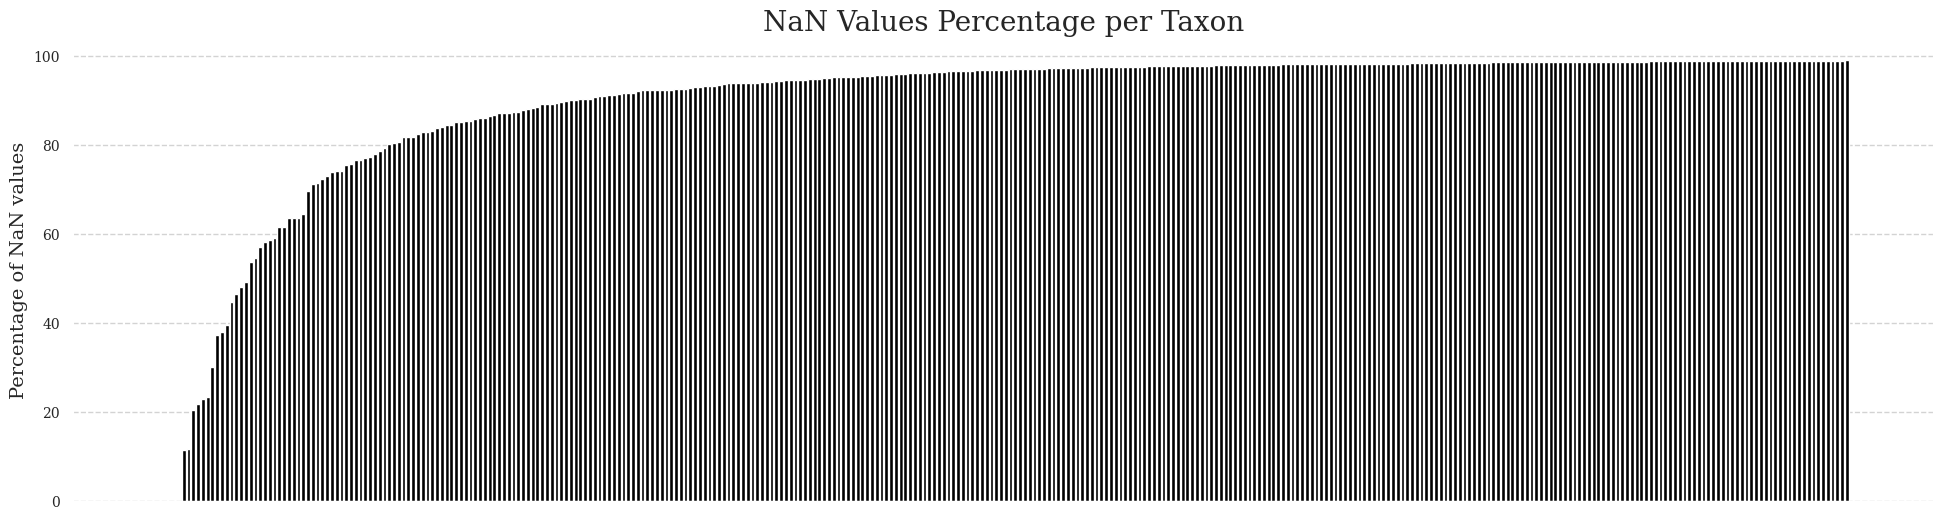

In [6]:
# Create a plot of NaN percentages per column
import matplotlib.pyplot as plt

# restart matplotlib
from scripts import style
style.mpl_apply()

plt.figure(figsize=(24, 6))
plt.bar(vals.index, vals.values, color='black')
plt.xticks(rotation=90)
plt.ylabel('Percentage of NaN values')
plt.title('NaN Values Percentage per Taxon')
# dont show x axis labels
plt.xticks([])
plt.show()


In [7]:
# display some rows
pd.set_option("display.max_columns", 8)
df

,SamplingOperations_code,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
2703,S02115200_20070702,2007-07-02,400,NaN,...,NaN,902925.0,6941112.0,10.5
33984,S05218450_20070709,2007-07-09,400,NaN,...,NaN,442885.0,6199880.0,20.0
33929,S05217350_20070709,2007-07-09,400,NaN,...,NaN,442250.0,6218040.0,20.0
48228,S05235850_20070709,2007-07-09,400,NaN,...,2.500000,463192.0,6225280.0,NaN
35408,S05234290_20070709,2007-07-09,400,NaN,...,10.000000,456573.0,6224410.0,16.6
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,2023-09-07,426,NaN,...,4.694836,908596.0,6499943.0,14.5
35760,S06001284_20230907,2023-09-07,421,NaN,...,87.885986,910629.0,6500149.0,16.3
35783,S06001533_20230907,2023-09-07,401,NaN,...,62.344140,909322.0,6499820.0,14.8
38878,S06137040_20231011,2023-10-11,400,NaN,...,10.000000,967828.0,6518569.0,20.0


In [8]:
# select the desired columns correctly using a list of column names
ibd = df[['SamplingOperations_code', 'Date_SamplingOperation', 'Longitude_Lambert93', 'Latitude_Lambert93', 'IBD']]
ibd = ibd.set_index('SamplingOperations_code', inplace=False)
ibd

,Date_SamplingOperation,Longitude_Lambert93,Latitude_Lambert93,IBD
SamplingOperations_code,,,,
S02115200_20070702,2007-07-02,902925.0,6941112.0,10.5
S05218450_20070709,2007-07-09,442885.0,6199880.0,20.0
S05217350_20070709,2007-07-09,442250.0,6218040.0,20.0
S05235850_20070709,2007-07-09,463192.0,6225280.0,NaN
S05234290_20070709,2007-07-09,456573.0,6224410.0,16.6
...,...,...,...,...
S06580577_20230907,2023-09-07,908596.0,6499943.0,14.5
S06001284_20230907,2023-09-07,910629.0,6500149.0,16.3
S06001533_20230907,2023-09-07,909322.0,6499820.0,14.8


# Fast IBD IDW interpolation with spatio-temporal scaling

In [ ]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

def _to_days(s):
    d = pd.to_datetime(s)
    return (d.view("int64") // 10**9 // 86400).astype(np.int64)

def _estimate_alpha(x, y, t_days):
    # spatial range: median 5-NN distance; temporal: median positive gap
    P = np.c_[x, y]
    n = len(P)
    k = min(6, max(2, n))
    nn = NearestNeighbors(n_neighbors=k).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]           # exclude self
    r_s = np.median(d) if d.size else 1.0
    ut = np.unique(t_days)
    gaps = np.diff(np.sort(ut))
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0
    return (r_s / r_t)**2
    # if alpha is too small, spatial dominates; if too large, temporal dominates

def fill_ibd_nans(ibd, k=32, power=2.0, min_pts=5, eps=1e-6):
    """
    Fill ibd['IBD'] NaNs via k-NN inverse-distance weighting in (x,y, sqrt(alpha)*t).
    Columns required: Date_SamplingOperation, Longitude_Lambert93, Latitude_Lambert93, IBD
    """
    df = ibd.copy()
    # prepare coords
    df = df.assign(
        _x = df["Longitude_Lambert93"].astype(float),
        _y = df["Latitude_Lambert93"].astype(float),
        _t = _to_days(df["Date_SamplingOperation"])
    )
    mask_known = df["IBD"].notna()
    mask_query = df["IBD"].isna() & df[["_x","_y","_t"]].notna().all(1)

    if mask_query.sum() == 0 or mask_known.sum() < min_pts:
        return df  # nothing to fill or not enough data

    xk = df.loc[mask_known, ["_x","_y"]].to_numpy()
    yk = df.loc[mask_known, "IBD"].to_numpy().astype(float)
    tk = df.loc[mask_known, "_t"].to_numpy()

    # scale time → choose alpha once
    alpha = _estimate_alpha(xk[:,0], xk[:,1], tk)
    print(f"Using alpha={alpha:.3f} for spatio-temporal scaling.")
    
    zk = np.c_[xk[:,0], xk[:,1], np.sqrt(alpha) * tk]

    # build kNN on known points
    kk = min(k, len(zk))
    nbrs = NearestNeighbors(n_neighbors=kk, algorithm="auto").fit(zk)

    # queries
    xq = df.loc[mask_query, ["_x","_y"]].to_numpy()
    tq = df.loc[mask_query, "_t"].to_numpy()
    zq = np.c_[xq[:,0], xq[:,1], np.sqrt(alpha) * tq]

    dist, idx = nbrs.kneighbors(zq, n_neighbors=kk, return_distance=True)

    # exact-match shortcut (distance ~ 0)
    exact = (dist[:,0] < 1e-9)
    out = np.empty(len(zq), dtype=float)

    if np.any(exact):
        out[exact] = yk[idx[exact,0]]

    # IDW for the rest
    rest = ~exact
    if np.any(rest):
        d = np.maximum(dist[rest], eps)
        w = 1.0 / np.power(d, power)
        y_nei = yk[idx[rest]]
        num = (w * y_nei).sum(axis=1)
        den = w.sum(axis=1)
        # if too few effective neighbors, leave NaN
        ok = (den > 0) & (np.isfinite(num))
        out_rest = np.full(rest.sum(), np.nan)
        out_rest[ok] = num[ok] / den[ok]
        out[rest] = out_rest

    # write back
    df.loc[mask_query, "IBD"] = out
    return df

In [11]:
ibd_filled = fill_ibd_nans(ibd, k=32, power=2.0)

C:\Users\herie\AppData\Local\Temp\ipykernel_24868\2859833689.py:6: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return (d.view("int64") // 10**9 // 86400).astype(np.int64)


In [12]:
ibd_filled

,Date_SamplingOperation,Longitude_Lambert93,Latitude_Lambert93,IBD,_x,_y,_t
SamplingOperations_code,,,,,,,
S02115200_20070702,2007-07-02,902925.0,6941112.0,10.5,902925.0,6941112.0,13696
S05218450_20070709,2007-07-09,442885.0,6199880.0,20.0,442885.0,6199880.0,13703
S05217350_20070709,2007-07-09,442250.0,6218040.0,20.0,442250.0,6218040.0,13703
S05235850_20070709,2007-07-09,463192.0,6225280.0,20.0,463192.0,6225280.0,13703
S05234290_20070709,2007-07-09,456573.0,6224410.0,16.6,456573.0,6224410.0,13703
...,...,...,...,...,...,...,...
S06580577_20230907,2023-09-07,908596.0,6499943.0,14.5,908596.0,6499943.0,19607
S06001284_20230907,2023-09-07,910629.0,6500149.0,16.3,910629.0,6500149.0,19607
S06001533_20230907,2023-09-07,909322.0,6499820.0,14.8,909322.0,6499820.0,19607


In [ ]:
from scripts import mapping

ranges = mapping.get_ranges(tol=1)
ranges

# get the IBD missing of the ibd_filled dataframe
# get the IBD missing of the
ibd_missing = ibd_filled[ibd['IBD'].isna()]['IBD']
# to dataframe
ibd_missing = ibd_missing.to_frame()

mapping.get_results(
    ibd_missing,
    ranges,
    pred_col="IBD",
    output_file="results/009_IBD_Interpolation/01_Fast_IBD_Interpolation_IDW_a0.csv",
    index=True,
)

# Fast IBD interpolation with Gaussian kernel and spatio-temporal scaling

In [41]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# ---------------- utilities ----------------
def _to_days(s):
    t = pd.to_datetime(s, errors="coerce").view("int64") // 86400_000_000_000
    return t.astype("int64")

def _estimate_alpha(x, y, t_days):
    P = np.c_[x, y]
    if len(P) < 3:
        return 1.0
    k = min(6, len(P))
    nn = NearestNeighbors(n_neighbors=k).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]
    r_s = np.median(d) if d.size else 1.0
    ut  = np.unique(t_days)
    gaps = np.diff(ut)
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0
    return (r_s / r_t)**2

def _weights(dist, kind="gaussian", power=2.0, eps=None):
    if kind == "gaussian":
        if eps is None:
            nz = dist[dist>1e-12]
            eps = np.median(nz) if nz.size else 1.0
        u = dist / eps
        return np.exp(-(u*u))
    # idw
    return 1.0 / np.maximum(dist, 1e-6)**power

# ---------------- main ----------------
def fill_ibd_nans(ibd,
                  k=32,
                  kernel="gaussian",   # "gaussian" or "idw"
                  power=2.0,           # only for idw
                  eps=None,            # None → auto from neighbor distances
                  alpha=None,          # None → auto from ranges
                  same_site_only=False,
                  site_col="CodeSite_SamplingOperations",
                  same_xy_tol=0.5):
    """
    Fill NaNs in 'IBD' using k-NN weighting in (x,y, sqrt(alpha)*t).
    Columns required: Date_SamplingOperation, Longitude_Lambert93, Latitude_Lambert93, IBD.
    """
    df = ibd.copy()
    df["_x"] = df["Longitude_Lambert93"].astype(float)
    df["_y"] = df["Latitude_Lambert93"].astype(float)
    df["_t"] = _to_days(df["Date_SamplingOperation"])

    mask_known = df["IBD"].notna()
    mask_query = df["IBD"].isna() & df[["_x","_y","_t"]].notna().all(1)
    if mask_query.sum() == 0 or mask_known.sum() < 3:
        return df

    xk = df.loc[mask_known, "_x"].to_numpy()
    yk = df.loc[mask_known, "_y"].to_numpy()
    tk = df.loc[mask_known, "_t"].to_numpy()
    zk = df.loc[mask_known, "IBD"].to_numpy().astype(float)

    if alpha is None:
        alpha = _estimate_alpha(xk, yk, tk)

    Zk = np.c_[xk, yk, np.sqrt(alpha)*tk]
    k_eff = min(k, len(Zk))
    nbrs = NearestNeighbors(n_neighbors=k_eff).fit(Zk)

    xq = df.loc[mask_query, "_x"].to_numpy()
    yq = df.loc[mask_query, "_y"].to_numpy()
    tq = df.loc[mask_query, "_t"].to_numpy()
    Zq = np.c_[xq, yq, np.sqrt(alpha)*tq]

    # Optional restriction: use only same-site neighbors
    if same_site_only:
        # by site id if available, else by XY tolerance
        out = np.full(len(Zq), np.nan, float)
        if site_col in df.columns:
            site_k = df.loc[mask_known, site_col].to_numpy()
            site_q = df.loc[mask_query, site_col].to_numpy()
            from collections import defaultdict
            bucket = defaultdict(list)
            for i,s in enumerate(site_k): bucket[s].append(i)
            for j, (zq, s) in enumerate(zip(Zq, site_q)):
                pool = np.array(bucket.get(s, []), dtype=int)
                if pool.size == 0:
                    # fallback to global neighbors
                    dist, idx = nbrs.kneighbors(zq.reshape(1,-1), return_distance=True)
                    dist, idx = dist[0], idx[0]
                else:
                    D = np.linalg.norm(Zk[pool] - zq, axis=1)
                    take = min(k_eff, len(pool))
                    order = np.argpartition(D, take-1)[:take]
                    idx = pool[order]
                    dist = D[order]
                if dist[0] < 1e-12:
                    out[j] = zk[idx[0]]
                else:
                    w = _weights(dist, kind=kernel, power=power, eps=eps)
                    out[j] = np.sum(w * zk[idx]) / np.sum(w)
    else:
        dist, idx = nbrs.kneighbors(Zq, return_distance=True)
        # exact matches
        exact = dist[:,0] < 1e-12
        out = np.empty(len(Zq), float)
        out[exact] = zk[idx[exact,0]]
        # rest
        rest = ~exact
        if np.any(rest):
            D = dist[rest]
            I = idx[rest]
            if kernel == "gaussian" and eps is None:
                nz = D[D>1e-12]
                eps_auto = np.median(nz) if nz.size else 1.0
            else:
                eps_auto = eps
            W = _weights(D, kind=kernel, power=power, eps=eps_auto)
            Y = zk[I]
            num = (W * Y).sum(1)
            den = W.sum(1)
            out[rest] = num / den

    df.loc[mask_query, "IBD"] = out
    return df  # if you need alpha, return (df, alpha)


In [ ]:
alpha = (20000/730)**2

ibd_filled = fill_ibd_nans(ibd, kernel="gaussian", k=32, alpha=alpha)

# get the IBD missing of the ibd_filled dataframe
# get the IBD missing of the
ibd_missing = ibd_filled[ibd['IBD'].isna()]['IBD']
# to dataframe
ibd_missing = ibd_missing.to_frame()

mapping.get_results(
    ibd_missing,
    ranges,
    pred_col="IBD",
    output_file="results/009_IBD_Interpolation/02_Fast_IBD_Interpolation_Gaussian_a750.csv",
    index=True,
)

Saved predictions to results/009_IBD_Interpolation/02_Fast_IBD_Interpolation_Gaussian.csv


C:\Users\herie\AppData\Local\Temp\ipykernel_24868\1316252281.py:6: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t = pd.to_datetime(s, errors="coerce").view("int64") // 86400_000_000_000


,IBD_EQR_Status
SamplingOperations_code,
S05235850_20070709,High
S05113000_20070723,Poor
S05082000_20070724,Poor
S05111500_20070724,Poor
S05086000_20070725,Moderate
...,...
S06173650_20230720,Moderate
S06076420_20230726,Good
S06830139_20230818,Good


# Rapids

In [ ]:
# conda:  conda create -n rapids -c rapidsai -c conda-forge rapids=24.08 python=3.10 cuda-version=12.2
import cupy as cp, cudf

In [10]:
import cupy as cp, cudf
# cudf means GPU DataFrame, to install you must follow the instructions at
# https://rapids.ai/start.html#get-rapids
from cuml.neighbors import NearestNeighbors
import numpy as np, pandas as pd

ModuleNotFoundError: No module named 'cudf'

In [2]:
# conda:  conda create -n rapids -c rapidsai -c conda-forge rapids=24.08 python=3.10 cuda-version=12.2


# ---------- prep on CPU ----------
df = ibd.reset_index()  # has SamplingOperations_code
df = df[df["IBD"].notna()].copy()
df["t_days"] = pd.to_datetime(df["Date_SamplingOperation"]).astype("datetime64[D]").astype(int)

xy = df[["Longitude_Lambert93","Latitude_Lambert93"]].to_numpy(np.float32)
t  = df["t_days"].to_numpy(np.float32)
z  = df["IBD"].to_numpy(np.float32)

# alpha from median spatial range / temporal gap
from sklearn.neighbors import NearestNeighbors as SKNN
rs = np.median(SKNN(6).fit(xy).kneighbors(return_distance=True)[0][:,1:].ravel())
tgaps = np.diff(np.unique(t))
rt = np.median(tgaps[tgaps>0]) if (tgaps>0).any() else 1.0
alpha = np.float32((rs/rt)**2)
t_scaled = np.sqrt(alpha) * t

# queries: all unique sites × all days
sites = ibd[["Longitude_Lambert93","Latitude_Lambert93"]].drop_duplicates().to_numpy(np.float32)
tmin, tmax = int(ibd["Date_SamplingOperation"].min().to_datetime64().astype("datetime64[D]").astype(int)), \
             int(ibd["Date_SamplingOperation"].max().to_datetime64().astype("datetime64[D]").astype(int))
Tq = np.arange(tmin, tmax+1, dtype=np.int32)

Xq = np.repeat(sites[:,0], len(Tq)).astype(np.float32)
Yq = np.repeat(sites[:,1], len(Tq)).astype(np.float32)
Tq_days = np.tile(Tq, len(sites)).astype(np.float32)
Tq_scaled = np.sqrt(alpha) * Tq_days

# ---------- move training to GPU ----------
X_train = cp.asarray(np.c_[xy, t_scaled])      # (n,3) float32
y_train = cp.asarray(z)

knn = NearestNeighbors(n_neighbors=64, algorithm="brute", metric="euclidean")
knn.fit(X_train)

def kernel_gaussian(dist, eps):
    u = dist / eps
    return cp.exp(-(u*u))

# auto scale ~ median neighbor distance in ST
# do one small probe to set eps
probe_idx = cp.random.choice(X_train.shape[0], size=min(5000, X_train.shape[0]), replace=False)
Dprobe, _ = knn.kneighbors(X_train[probe_idx], return_distance=True)
eps = cp.median(Dprobe[:,1:]).item()  # exclude self

# ---------- batched prediction ----------
batch = 200_000   # tune for your 8–12 GB VRAM
out = np.empty_like(Tq_scaled, dtype=np.float32)

for start in range(0, len(Tq_scaled), batch):
    end = min(start+batch, len(Tq_scaled))
    Xq_gpu = cp.asarray(np.c_[Xq[start:end], Yq[start:end], Tq_scaled[start:end]])
    D, I = knn.kneighbors(Xq_gpu, return_distance=True)     # D:(B,k) float32
    W = kernel_gaussian(D, eps)                             # weights (B,k)
    Wsum = cp.maximum(W.sum(axis=1, keepdims=True), 1e-12)
    z_nei = y_train[I]                                      # gather (B,k)
    z_hat = (W * z_nei).sum(axis=1, keepdims=False) / Wsum.squeeze()
    out[start:end] = cp.asnumpy(z_hat)
    del Xq_gpu, D, I, W, Wsum, z_nei, z_hat
    cp.get_default_memory_pool().free_all_blocks()

# ---------- back to DataFrame ----------
out_df = pd.DataFrame({
    "Longitude_Lambert93": Xq.astype(np.float64),
    "Latitude_Lambert93":  Yq.astype(np.float64),
    "Date_SamplingOperation": pd.to_datetime(Tq_days.astype(np.int64), unit="D"),
    "IBD_hat": out.astype(np.float32)
})


ModuleNotFoundError: No module named 'cupy'

# Robust Alpha is for a lot of NaNs 

In [10]:
# This is made only if there are many NaN values in the IBD column

import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

def robust_alpha_from_design(df):
    # spatial median 5-NN distance
    P = df[["Longitude_Lambert93","Latitude_Lambert93"]].to_numpy()
    nn = NearestNeighbors(n_neighbors=6).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]   # 5 nearest
    r_s = np.median(d)

    # temporal median per-site gap (days), independent of IBD NaNs
    g = (df.assign(t=pd.to_datetime(df["Date_SamplingOperation"]).values.astype("datetime64[D]").astype(int))
            .reset_index()[["SamplingOperations_code","t"]])
    # site code = text before last '_' in SamplingOperations_code
    sites = g["SamplingOperations_code"].str.rsplit('_', n=1, regex=False).str[0]
    g["site"] = sites
    gaps = (g.sort_values(["site","t"])
              .groupby("site")["t"]
              .apply(lambda v: np.diff(v.unique())))
    r_t = np.median(np.concatenate([a[a>0] for a in gaps.values if a.size>0])) if len(gaps) else 1.0

    return (r_s / max(r_t,1.0))**2


In [11]:
import numpy as np, pandas as pd, pyarrow as pa, pyarrow.parquet as pq
from sklearn.neighbors import NearestNeighbors

def days(a): return np.asarray(pd.to_datetime(a), 'datetime64[D]').astype('int64')

def estimate_alpha(x, y, t_days):
    from sklearn.neighbors import NearestNeighbors
    P = np.c_[x, y].astype(np.float32)
    nn = NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]
    r_s = float(np.median(d))
    gaps = np.diff(np.unique(t_days))
    r_t = float(np.median(gaps[gaps>0])) if np.any(gaps>0) else 1.0
    return (r_s / r_t)**2

def gaussian_kernel(dist, eps):
    u = dist / eps
    return np.exp(-(u*u))

def build_index(x, y, t, alpha, n_neighbors=48, algo="kd_tree"):
    Z = np.c_[x, y, np.sqrt(alpha)*t].astype(np.float32)
    nn = NearestNeighbors(n_neighbors=n_neighbors, algorithm=algo).fit(Z)
    return nn

def predict_batch(nn, x, y, t, z, alpha, Xq, Yq, tq, k=32, eps=None, time_window=None):
    # time_window in days; filter neighbors by |t - tq| if given
    Zq = np.c_[Xq, Yq, np.full_like(Xq, np.sqrt(alpha)*tq)].astype(np.float32)
    dist, idx = nn.kneighbors(Zq, n_neighbors=k, return_distance=True)
    y_nei = z[idx]
    # optional temporal filtering
    if time_window is not None:
        mask = (np.abs(t[idx] - tq) <= time_window)
        # fallback if a row loses all neighbors
        atleast1 = mask.any(1)
        if not np.all(atleast1):
            mask[~atleast1, :] = True  # keep original neighbors if empty
        y_nei = np.where(mask, y_nei, np.nan)
        dist   = np.where(mask, dist, np.inf)
    # kernel scale
    if eps is None:
        # robust median over finite distances
        finite = np.isfinite(dist)
        med = np.median(dist[finite]) if np.any(finite) else 1.0
        eps = max(med, 1e-6)
    w = gaussian_kernel(dist, eps)
    w[~np.isfinite(w)] = 0.0
    wsum = w.sum(1)
    # inverse-distance rescue if all weights ~ 0
    bad = (wsum <= 1e-12)
    if np.any(bad):
        invd = 1.0 / (dist[bad] + 1e-6)
        w[bad] = invd
        wsum[bad] = invd.sum(1)
    return (w * y_nei).sum(1) / wsum

def interpolate_ibd_daily_stream(ibd, out_path="ibd_daily.parquet",
                                 k=32, time_window=90, algo="kd_tree", chunk_days=30):
    df = ibd.copy()
    df["t"] = days(df["Date_SamplingOperation"]).astype(np.int64)
    tr = df.loc[df["IBD"].notna(), ["Longitude_Lambert93","Latitude_Lambert93","t","IBD"]].to_numpy(dtype=np.float32)
    x, y, t, z = tr[:,0], tr[:,1], tr[:,2].astype(np.int64), tr[:,3]
    # unique sites (or pass your own grid)
    sites = df[["Longitude_Lambert93","Latitude_Lambert93"]].drop_duplicates().to_numpy(dtype=np.float32)
    Xs, Ys = sites[:,0], sites[:,1]
    # scale
    alpha = estimate_alpha(x, y, t)
    nn = build_index(x, y, t, alpha, n_neighbors=max(k, 48), algo=algo)

    tmin, tmax = int(df["t"].min()), int(df["t"].max())
    writer = None
    for start in range(tmin, tmax+1, chunk_days):
        days_chunk = np.arange(start, min(start+chunk_days-1, tmax)+1, dtype=int)
        parts = []
        for tq in days_chunk:
            zhat = predict_batch(nn, x, y, t, z, alpha, Xs, Ys, tq, k=k,
                                 eps=None, time_window=time_window)
            parts.append(pd.DataFrame({
                "Longitude_Lambert93": Xs,
                "Latitude_Lambert93":  Ys,
                "Date_SamplingOperation": pd.to_datetime(tq, unit="D"),
                "IBD_hat": zhat.astype(np.float32)
            }))
        out_chunk = pd.concat(parts, ignore_index=True)
        # append to parquet incrementally
        table = pa.Table.from_pandas(out_chunk)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema)
        writer.write_table(table)
    if writer is not None:
        writer.close()
    return alpha


In [45]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# --------- helpers ---------
def days(dt): return np.asarray(pd.to_datetime(dt), 'datetime64[D]').astype('int64')

def estimate_alpha(x, y, t_days):
    # spatial range ≈ median 5-NN distance; temporal range ≈ median gap
    P = np.c_[x, y]
    nn = NearestNeighbors(n_neighbors=6).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]             # 5 NNs
    r_s = np.median(d)                                           # meters
    gaps = np.diff(np.sort(np.unique(t_days)))
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0     # days
    return (r_s / r_t)**2

def kernel(dist, kind="gaussian", eps=None):
    # dist >= 0; eps is a scale. Default: median neighbor distance.
    if eps is None: eps = np.median(dist[dist>0]) if np.any(dist>0) else 1.0
    u = dist / eps
    if kind == "gaussian":      return np.exp(-(u**2))
    if kind == "multiquadric":  return np.sqrt(1.0 + u**2)
    if kind == "imq":           return 1.0 / np.sqrt(1.0 + u**2)
    if kind == "linear":        return np.maximum(1.0 - u, 0.0)
    raise ValueError("unknown kernel")

def build_st_index(x, y, t_days, alpha):
    tz = np.sqrt(alpha) * t_days
    Z  = np.c_[x, y, tz]
    nbrs = NearestNeighbors(n_neighbors=64, algorithm="auto").fit(Z)
    return nbrs

def predict_st_kernel(x, y, t_days, z,
                      xq, yq, tq_days,
                      alpha, k=64, kind="gaussian", eps=None, min_pts=8):
    # training index
    nbrs = build_st_index(x, y, t_days, alpha)
    tqz  = np.sqrt(alpha) * tq_days
    Zq   = np.c_[xq, yq, tqz]
    # kNN in space–time
    dist, idx = nbrs.kneighbors(Zq, n_neighbors=k, return_distance=True)
    # kernel weights and predictions
    w = kernel(dist, kind=kind, eps=eps)
    # guard: if too few neighbors or all weights tiny, fall back to inverse distance
    wsum = w.sum(1)
    bad  = (wsum <= 1e-12)
    if np.any(bad):
        w[bad] = 1.0 / (dist[bad] + 1e-6)
        wsum[bad] = w[bad].sum(1)
    y_nei = z[idx]
    return (w * y_nei).sum(1) / wsum

# --------- main driver for your df ---------
def interpolate_ibd_daily(ibd_df, k=64, kernel_kind="gaussian", eps=None,
                          sites="unique"):
    df = ibd_df.copy()
    # from float64 to float32
    df[["Longitude_Lambert93","Latitude_Lambert93","IBD"]] = df[["Longitude_Lambert93","Latitude_Lambert93","IBD"]].astype(np.float32)
    df["t"] = days(df["Date_SamplingOperation"])
    df = df.sort_values("t")
    # training data (drop NaN IBD)
    tr = df.loc[df["IBD"].notna(), ["Longitude_Lambert93","Latitude_Lambert93","t","IBD"]].to_numpy()
    x, y, t, z = tr[:,0], tr[:,1], tr[:,2], tr[:,3]
    # alpha from data
    alpha = estimate_alpha(x, y, t)
    # query sites
    if sites == "unique":
        sites_xy = df[["Longitude_Lambert93","Latitude_Lambert93"]].drop_duplicates().to_numpy()
    elif isinstance(sites, np.ndarray):
        sites_xy = sites
    else:
        raise ValueError("sites must be 'unique' or an array of shape (m,2)")
    # daily timeline
    tmin, tmax = int(df["t"].min()), int(df["t"].max())
    Tq = np.arange(tmin, tmax + 1, dtype=int)
    # cartesian product of sites × days
    Xq = np.repeat(sites_xy[:,0], len(Tq))
    Yq = np.repeat(sites_xy[:,1], len(Tq))
    TQ = np.tile(Tq, len(sites_xy))
    # predict
    Zq = predict_st_kernel(x, y, t, z, Xq, Yq, TQ, alpha, k=k, kind=kernel_kind, eps=eps)
    # package result
    out = pd.DataFrame({
        "Longitude_Lambert93": Xq,
        "Latitude_Lambert93":  Yq,
        "Date_SamplingOperation": pd.to_datetime(TQ, unit="D"),
        "IBD_hat": Zq
    })
    return out, alpha

# ---- usage ----
# ibd is your DataFrame indexed by SamplingOperations_code
# 


In [ ]:
out_df, alpha = interpolate_ibd_daily(ibd, k=32, kernel_kind="gaussian")
# out_df has one interpolated IBD per unique site per day across the observed date range.

In [ ]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# --------- helpers ---------
def days(dt): return np.asarray(pd.to_datetime(dt), 'datetime64[D]').astype('int64')

def estimate_alpha(x, y, t_days):
    # spatial range ≈ median 5-NN distance; temporal range ≈ median gap
    P = np.c_[x, y]
    nn = NearestNeighbors(n_neighbors=6).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]             # 5 NNs
    r_s = np.median(d)                                           # meters
    gaps = np.diff(np.sort(np.unique(t_days)))
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0     # days
    return (r_s / r_t)**2

def kernel(dist, kind="gaussian", eps=None):
    # dist >= 0; eps is a scale. Default: median neighbor distance.
    if eps is None: eps = np.median(dist[dist>0]) if np.any(dist>0) else 1.0
    u = dist / eps
    if kind == "gaussian":      return np.exp(-(u**2))
    if kind == "multiquadric":  return np.sqrt(1.0 + u**2)
    if kind == "imq":           return 1.0 / np.sqrt(1.0 + u**2)
    if kind == "linear":        return np.maximum(1.0 - u, 0.0)
    raise ValueError("unknown kernel")

def build_st_index(x, y, t_days, alpha):
    tz = np.sqrt(alpha) * t_days
    Z  = np.c_[x, y, tz]
    nbrs = NearestNeighbors(n_neighbors=64, algorithm="auto").fit(Z)
    return nbrs

def predict_st_kernel(x, y, t_days, z,
                      xq, yq, tq_days,
                      alpha, k=64, kind="gaussian", eps=None, min_pts=8):
    # training index
    nbrs = build_st_index(x, y, t_days, alpha)
    tqz  = np.sqrt(alpha) * tq_days
    Zq   = np.c_[xq, yq, tqz]
    # kNN in space–time
    dist, idx = nbrs.kneighbors(Zq, n_neighbors=k, return_distance=True)
    # kernel weights and predictions
    w = kernel(dist, kind=kind, eps=eps)
    # guard: if too few neighbors or all weights tiny, fall back to inverse distance
    wsum = w.sum(1)
    bad  = (wsum <= 1e-12)
    if np.any(bad):
        w[bad] = 1.0 / (dist[bad] + 1e-6)
        wsum[bad] = w[bad].sum(1)
    y_nei = z[idx]
    return (w * y_nei).sum(1) / wsum

# --------- main driver for your df ---------
def interpolate_ibd_daily(ibd_df, k=64, kernel_kind="gaussian", eps=None,
                          sites="unique"):
    df = ibd_df.copy()
    df["t"] = days(df["Date_SamplingOperation"])
    df = df.sort_values("t")
    # training data (drop NaN IBD)
    tr = df.loc[df["IBD"].notna(), ["Longitude_Lambert93","Latitude_Lambert93","t","IBD"]].to_numpy()
    x, y, t, z = tr[:,0], tr[:,1], tr[:,2], tr[:,3]
    # alpha from data
    alpha = estimate_alpha(x, y, t)
    # query sites
    if sites == "unique":
        sites_xy = df[["Longitude_Lambert93","Latitude_Lambert93"]].drop_duplicates().to_numpy()
    elif isinstance(sites, np.ndarray):
        sites_xy = sites
    else:
        raise ValueError("sites must be 'unique' or an array of shape (m,2)")
    # daily timeline
    tmin, tmax = int(df["t"].min()), int(df["t"].max())
    Tq = np.arange(tmin, tmax + 1, dtype=int)
    # cartesian product of sites × days
    Xq = np.repeat(sites_xy[:,0], len(Tq))
    Yq = np.repeat(sites_xy[:,1], len(Tq))
    TQ = np.tile(Tq, len(sites_xy))
    # predict
    Zq = predict_st_kernel(x, y, t, z, Xq, Yq, TQ, alpha, k=k, kind=kernel_kind, eps=eps)
    # package result
    out = pd.DataFrame({
        "Longitude_Lambert93": Xq,
        "Latitude_Lambert93":  Yq,
        "Date_SamplingOperation": pd.to_datetime(TQ, unit="D"),
        "IBD_hat": Zq
    })
    return out, alpha

# ---- usage ----
# ibd is your DataFrame indexed by SamplingOperations_code
# out_df, alpha = interpolate_ibd_daily(ibd, k=64, kernel_kind="gaussian")
# out_df has one interpolated IBD per unique site per day across the observed date range.


In [ ]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# This function converts datetime to integer days
def _days(dt): return np.asarray(pd.to_datetime(dt), 'datetime64[D]').astype('int64')

# This function estimates the alpha parameter for space-time interpolation
# the alpha parameter balances spatial and temporal distances
# for example, if alpha is large, temporal distances are more important
# if alpha is small, spatial distances are more important
def _estimate_alpha(x, y, t_days):
    # let P be the spatial points
    # the function c_[x,y] concatenates x and y as columns
    P = np.c_[x,y]
    # let nn be the nearest neighbors model
    # the nn connects each point to its 6 nearest neighbors

    nn = NearestNeighbors(n_neighbors=6).fit(P)
    # let r_s be the median spatial distance between neighbors
    # the function kneighbors returns the distances and indices of the neighbors
    # the median spatial distance is literaly the median of the distances to the nearest neighbors
    # we ignore the first column (distance to itself, which is zero)
    r_s = np.median(nn.kneighbors(return_distance=True)[0][:,1:])

    # let gaps be the sorted unique time differences between observations
    # the function np.diff computes the n-th discrete difference along the given axis
    gaps = np.diff(np.sort(np.unique(t_days)))
    # let r_t be the median temporal gap between observations
    # we consider only positive gaps (greater than zero)
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0       # days
    # return the ratio of squared spatial and temporal distances
    # if alpha is gratert than 1, spatial distances are more important
    # if alpha is less than 1, temporal distances are more important
    # the importance is measured by the distance of influence
    # for example, if alpha is 4, spatial distances have 4 times more influence than temporal distances, this could because the phenomenon being modeled is more spatially correlated than temporally correlated, because it changes slowly over time or there not are many observations over time
    return (r_s / r_t)**2

def _kernel(d, eps=None):
    # let d be the distances
    # let eps be the bandwidth parameter
    if eps is None: eps = np.median(d[d>0]) if np.any(d>0) else 1.0
    u = d / eps
    return np.exp(-(u*u))  # Gaussian

def _build_index(x,y,t,alpha):
    Z = np.c_[x, y, np.sqrt(alpha)*t]
    return NearestNeighbors(n_neighbors=64).fit(Z)

def st_predict_grid(x,y,t,z, alpha, xg, yg, tq_days, k=64, eps=None):
    # neighbors in (x,y, sqrt(alpha)*t)
    nbrs = _build_index(x,y,t,alpha)
    XQ,YQ = np.meshgrid(xg, yg, indexing='xy')
    Zq = np.c_[XQ.ravel(), YQ.ravel(), np.full(XQ.size, np.sqrt(alpha)*tq_days)]
    dist, idx = nbrs.kneighbors(Zq, n_neighbors=k, return_distance=True)
    w = _kernel(dist, eps=eps); ws = w.sum(1)
    ynei = z[idx]
    grid = (w* ynei).sum(1) / np.maximum(ws, 1e-12)
    return XQ, YQ, grid.reshape(XQ.shape)


In [11]:
# ibd: index=SamplingOperations_code
df = ibd.reset_index().copy()
df["t"] = _days(df["Date_SamplingOperation"])
ok = df["IBD"].notna()
x, y, t, z = (df.loc[ok,"Longitude_Lambert93"].to_numpy(),
              df.loc[ok,"Latitude_Lambert93"].to_numpy(),
              df.loc[ok,"t"].to_numpy(),
              df.loc[ok,"IBD"].to_numpy())

alpha = _estimate_alpha(x,y,t)  # space–time balance
# grid (meters, Lambert-93); choose ~1–5 km step as needed
dx = dy = 2000
xg = np.arange(x.min(), x.max()+dx, dx)
yg = np.arange(y.min(), y.max()+dy, dy)


In [31]:
xg

array([ 132508.,  134508.,  136508.,  138508.,  140508.,  142508.,
        144508.,  146508.,  148508.,  150508.,  152508.,  154508.,
        156508.,  158508.,  160508.,  162508.,  164508.,  166508.,
        168508.,  170508.,  172508.,  174508.,  176508.,  178508.,
        180508.,  182508.,  184508.,  186508.,  188508.,  190508.,
        192508.,  194508.,  196508.,  198508.,  200508.,  202508.,
        204508.,  206508.,  208508.,  210508.,  212508.,  214508.,
        216508.,  218508.,  220508.,  222508.,  224508.,  226508.,
        228508.,  230508.,  232508.,  234508.,  236508.,  238508.,
        240508.,  242508.,  244508.,  246508.,  248508.,  250508.,
        252508.,  254508.,  256508.,  258508.,  260508.,  262508.,
        264508.,  266508.,  268508.,  270508.,  272508.,  274508.,
        276508.,  278508.,  280508.,  282508.,  284508.,  286508.,
        288508.,  290508.,  292508.,  294508.,  296508.,  298508.,
        300508.,  302508.,  304508.,  306508.,  308508.,  3105

In [26]:
import matplotlib.pyplot as plt

def plot_ibd_map_for_date(date_str, vmin=None, vmax=None, eps=None, k=64):
    tq = _days(date_str)
    XQ, YQ, G = st_predict_grid(x,y,t,z, alpha, xg, yg, tq, k=k, eps=eps)
    vmin = np.nanmin(G) if vmin is None else vmin
    vmax = np.nanmax(G) if vmax is None else vmax

    plt.figure(figsize=(7,6))
    im = plt.pcolormesh(XQ, YQ, G, shading='auto', vmin=vmin, vmax=vmax, cmap="viridis")
    plt.scatter(x, y, c='k', s=1, alpha=0.1)  # station locations
    plt.colorbar(im,label="IBD (interpolated)")
    plt.title(f"IBD space–time interpolation — {pd.to_datetime(date_str).date()}")
    plt.xlabel("Lambert-93 X [m]"); plt.ylabel("Lambert-93 Y [m]")
    plt.tight_layout(); plt.show()

# Example:
# 


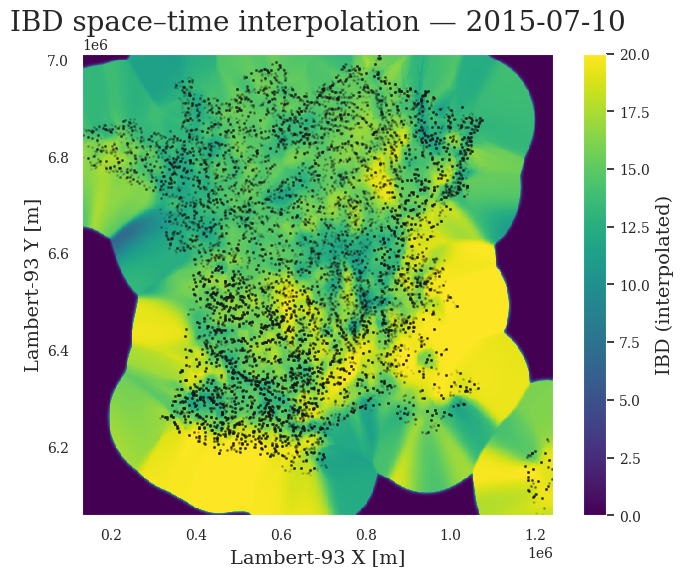

In [27]:
plot_ibd_map_for_date("2015-07-10", k=64)

In [33]:
from matplotlib.animation import FuncAnimation, PillowWriter

def animate_ibd(start, end, step_days=7, k=64, eps=None, out="ibd_timelapse.gif"):
    t0, t1 = _days(start), _days(end)
    TQ = np.arange(t0, t1+1, step_days)
    # precompute global vmin/vmax for stable colors
    vals = []
    for tq in TQ:
        _,_,G = st_predict_grid(x,y,t,z, alpha, xg, yg, tq, k=k, eps=eps)
        vals.append(G)
    vmin = np.nanmin([g.min() for g in vals])
    vmax = np.nanmax([g.max() for g in vals])

    fig, ax = plt.subplots(figsize=(7,6))
    XQ, YQ, G0 = st_predict_grid(x,y,t,z, alpha, xg, yg, TQ[0], k=k, eps=eps)
    im = ax.pcolormesh(XQ, YQ, G0, shading='auto', vmin=vmin, vmax=vmax, cmap="viridis")
    scat = ax.scatter(x, y, c='k', s=4, alpha=0.4)
    cb = fig.colorbar(im, ax=ax, label="IBD"); ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")

    def upd(i):
        tq = TQ[i]
        _,_,G = st_predict_grid(x,y,t,z, alpha, xg, yg, tq, k=k, eps=eps)
        im.set_array(G.ravel())
        ax.set_title(f"IBD interpolation — {pd.to_datetime(tq, unit='D').date()}")
        return im,

    ani = FuncAnimation(fig, upd, frames=len(TQ), interval=200, blit=False)

    ani.save(out, writer=PillowWriter(fps=6))

    plt.close(fig)

# Example:
# animate_ibd("2010-01-01", "2010-12-31", step_days=14, k=64, out="ibd_2010.gif")
animate_ibd("2010-01-01", "2010-12-31", step_days=14, k=64, out="ibd_2010.gif")
